In [13]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

set_seeds()

In [16]:
# 0. Import necessary modules
from transformers import AutoModelForImageClassification, AutoTokenizer

# 1. Get pretrained weights for ViT-Base from Hugging Face
pretrained_vit_weights = "google/vit-base-patch16-224"

# 2. Setup a ViT model instance with pretrained weights from Hugging Face
pretrained_vit = AutoModelForImageClassification.from_pretrained(pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.base_model.parameters():
    parameter.requires_grad = False

# 4. Change the number of output classes
class_names = ['mutu1', 'mutu2', 'mutu3', 'mutu4', 'mutu5', 'mutu6']
pretrained_vit.classifier = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

# Set the model to evaluation mode
pretrained_vit.eval()

# 5. Define the transforms for your dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Let's make Prediction:

In [17]:
import os

pred_class_path = '/kaggle/input/prediction-arabica-class/pred_class'
pred_list = []

for root, dirs, files in os.walk(pred_class_path):
    for file in files:
        if file.endswith('.jpg'):
            pred_list.append((os.path.join(root, file), class_names.index(root.split('/')[-1])))

pred_list.sort(key=lambda x: x[1])
pred_list = [item[0] for item in pred_list]

In [18]:
# Load the model weights
model_weights = torch.load('/kaggle/input/vit-arabica-weight/weight_vit/vit-hgfc-16(8020).pth')

# Create a model instance and load the weights into it
model = pretrained_vit
model.load_state_dict(model_weights)

<All keys matched successfully>

In [19]:
import itertools

actual_labels = [name for name in itertools.chain.from_iterable(itertools.repeat(class_name, 10) for class_name in class_names)]

In [20]:
def predict_image(image_path, model, class_names):
    # Load the image
    image = Image.open(image_path)

    # Define transformations to be applied to the image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize the image to the expected input size of the model
        transforms.ToTensor(),           # Convert the image to a PyTorch tensor
        transforms.Normalize(            # Normalize the image
            mean=[0.485, 0.456, 0.406],   # Mean and standard deviation values for ImageNet dataset
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Apply the transformations to the image
    input_image = transform(image).unsqueeze(0)  # Add batch dimension

    # Set the device to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the input tensor to the device
    input_image = input_image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform inference
    with torch.no_grad():
        outputs = model(input_image)

    # Get the logits from the output object
    logits = outputs.logits

    # Apply softmax to get probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Get the predicted class index
    predicted_class_idx = torch.argmax(probabilities).item()

    # Get the class label corresponding to the predicted index
    predicted_class_label = class_names[predicted_class_idx]

    # Get the probability score for the predicted class
    predicted_probability = probabilities[0, predicted_class_idx].item()
    
    # Get predicted labels
    predicted_labels.append(predicted_class_label)


In [21]:
from PIL import Image
import time  # Import modul time

# Get predicted labels
predicted_labels = []

prediction_times = []  # List to store prediction times
    
# Get prediction images    
image_paths = pred_list

times = []

# Iterate over the images and make predictions
for image_path in image_paths:
    start_time = time.time()  # Start time
    predict_image(image_path, model, class_names)
    end_time = time.time()  # End time        times.append(end_time - start_time)
    times.append(end_time - start_time)
    
#prediction_times.append(np.mean(times))  # Store the average prediction time
times

[0.1621687412261963,
 0.16868925094604492,
 0.16824626922607422,
 0.16687464714050293,
 0.16919159889221191,
 0.1691572666168213,
 0.16411161422729492,
 0.1715104579925537,
 0.1639106273651123,
 0.16928625106811523,
 0.17269372940063477,
 0.16796517372131348,
 0.16662812232971191,
 0.17274689674377441,
 0.16783714294433594,
 0.16278982162475586,
 0.1813197135925293,
 0.16866159439086914,
 0.16094541549682617,
 0.16239595413208008,
 0.15732502937316895,
 0.1577591896057129,
 0.15621376037597656,
 0.15474915504455566,
 0.15794587135314941,
 0.15802526473999023,
 0.15738844871520996,
 0.15810537338256836,
 0.15700745582580566,
 0.156693696975708,
 0.15549945831298828,
 0.16694927215576172,
 0.1562507152557373,
 0.16312456130981445,
 0.1538538932800293,
 0.15900111198425293,
 0.1600031852722168,
 0.1530618667602539,
 0.15594959259033203,
 0.15756821632385254,
 0.15507268905639648,
 0.15600848197937012,
 0.15674090385437012,
 0.15529680252075195,
 0.15595269203186035,
 0.14425253868103027,


In [22]:
predicted_labels

['mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu1',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu2',
 'mutu3',
 'mutu3',
 'mutu3',
 'mutu3',
 'mutu3',
 'mutu3',
 'mutu3',
 'mutu2',
 'mutu3',
 'mutu4',
 'mutu3',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu4',
 'mutu5',
 'mutu3',
 'mutu5',
 'mutu5',
 'mutu5',
 'mutu5',
 'mutu5',
 'mutu6',
 'mutu5',
 'mutu3',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6',
 'mutu6']

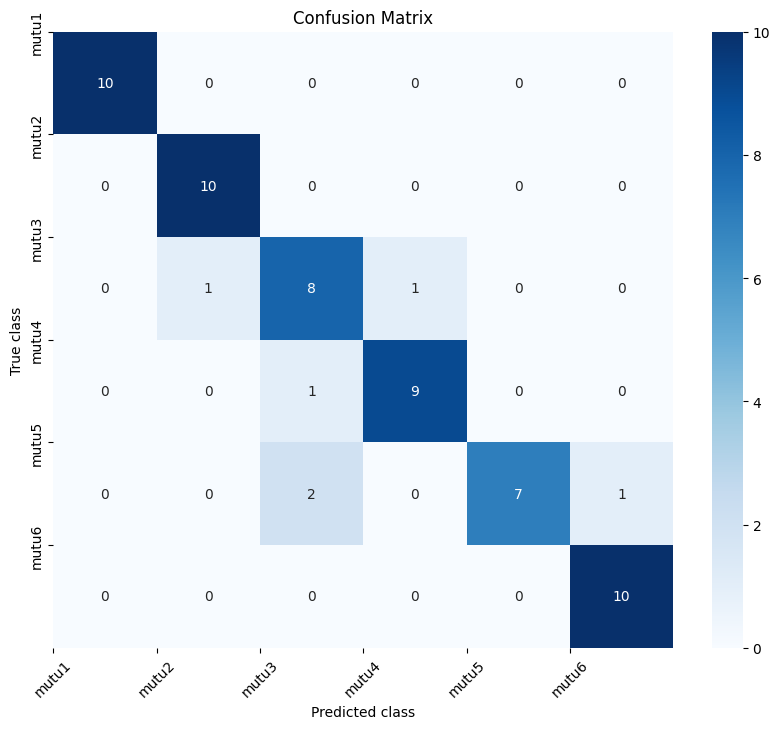

In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_confusion_matrix(actual_labels, predicted_labels):
    cm = confusion_matrix(actual_labels, predicted_labels)
    return cm

confusion_matrix_data = calculate_confusion_matrix(actual_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_data, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.show()

In [24]:
accuracy = np.trace(confusion_matrix_data) / np.sum(confusion_matrix_data)
precision = np.diag(confusion_matrix_data) / np.sum(confusion_matrix_data, axis=0)
recall = np.diag(confusion_matrix_data) / np.sum(confusion_matrix_data, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print(f"Average Prediction Time per Image: {np.mean(times)} seconds")  # Print average prediction time

Accuracy: 0.9
Precision: [1.         0.90909091 0.72727273 0.9        1.         0.90909091]
Recall: [1.  1.  0.8 0.9 0.7 1. ]
F1 Score: [1.         0.95238095 0.76190476 0.9        0.82352941 0.95238095]
Average Prediction Time per Image: 0.16279908816019695 seconds
